In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료!")
print(f"Pandas 버전: {pd.__version__}")

SIA Wevengers 분석 환경 준비 완료!
Pandas 버전: 2.3.3


In [4]:
import pandas_gbq

query = """
SELECT SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long
FROM `gdelt-bq.full.events`
WHERE Year = 2013 
  AND ((Actor1Code = 'CHN' AND Actor2Code = 'TWN') OR 
       (Actor1Code = 'TWN' AND Actor2Code = 'CHN'))
"""

# 프로젝트 ID 입력 후 바로 Pandas DataFrame으로 변환
project_id = "gdelt-analysis-494301"
df = pandas_gbq.read_gbq(query, project_id=project_id)

print(df.head())

Downloading: 100%|██████████|
    SQLDATE EventCode  GoldsteinScale  ActionGeo_Lat  ActionGeo_Long
0  20131231       120            -4.0        39.9289         116.388
1  20131231       120            -4.0        25.0478         121.532
2  20130205       043             2.8        25.0478         121.532
3  20130205       042             1.9        25.0478         121.532
4  20130512       012            -0.4        25.0478         121.532


In [5]:
from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'gdelt-analysis-494301'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [5]:
# 양안관계 데이터 쿼리 (위도, 경도 포함)
taiwain_query = """
SELECT SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long, SOURCEURL
FROM `gdelt-bq.full.events`
WHERE Year = 2013 
  AND ((Actor1Code = 'CHN' AND Actor2Code = 'TWN') OR 
       (Actor1Code = 'TWN' AND Actor2Code = 'CHN'))
"""

# 동일한 credentials를 사용하여 데이터 가져오기
df = pandas_gbq.read_gbq(taiwain_query, project_id=project_id, credentials=credentials)

# 결과 확인
print(f"가져온 데이터 행 수: {len(df)}")
display(df.head())

Downloading: 100%|██████████|
가져온 데이터 행 수: 7088


,SQLDATE,EventCode,GoldsteinScale,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20131205,181,-9.0,35.0000,105.000,http://www.globalpost.com/dispatch/news/afp/13...
1,20131029,025,-0.3,-41.0000,174.000,http://www.taipeitimes.com/News/taiwan/archive...
2,20131127,128,-5.0,23.5000,121.000,http://ajw.asahi.com/article/asia/AJ201311270079
3,20131227,194,-10.0,23.5000,121.000,http://www.wantchinatimes.com/news-subclass-cn...
4,20131016,054,6.0,39.9289,116.388,https://www.wsws.org/en/articles/2013/10/16/ta...


GoldsteinScale 분석

C:\Users\Jua\AppData\Local\Temp\ipykernel_23912\1138552633.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_goldstein = df['GoldsteinScale'].resample('M').mean()


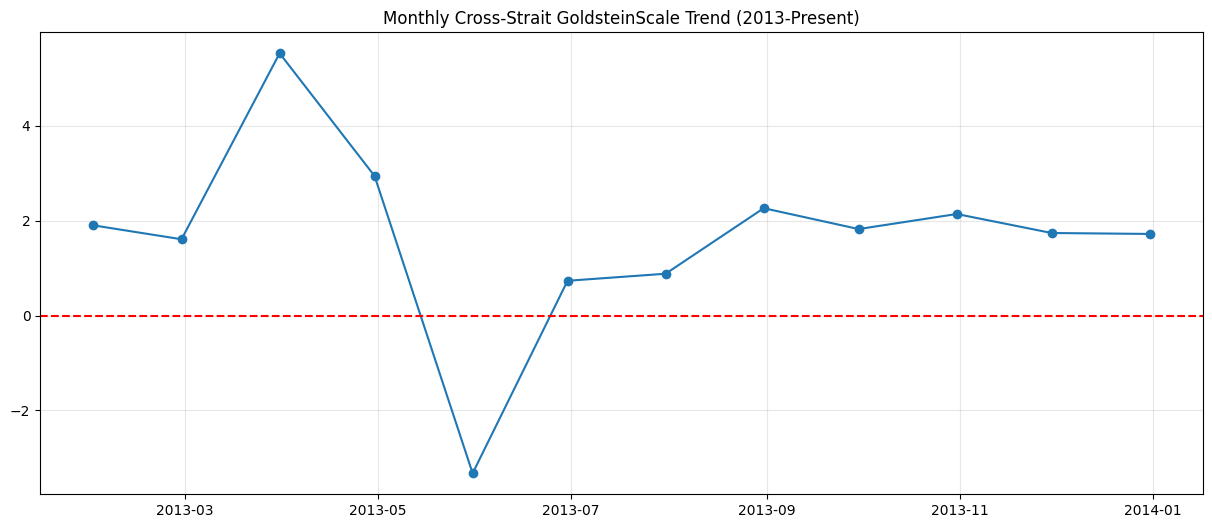

In [7]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
df = df.sort_values('SQLDATE')
df.set_index('SQLDATE', inplace=True) # 날짜를 인덱스로 설정

# 데이터가 너무 많아서 'M'으로 먼저 그려봄
# 'M'은 월 단위(Month) 평균, 주 단위(Week) 평균은 'W'
monthly_goldstein = df['GoldsteinScale'].resample('M').mean()

plt.figure(figsize=(15, 6))
plt.plot(monthly_goldstein.index, monthly_goldstein.values, marker='o', linestyle='-')
plt.title('Monthly Cross-Strait GoldsteinScale Trend (2013-Present)')
plt.axhline(0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# GoldsteinScale이 -5.0 이하인 '심각한 갈등' 상황만 추출
extreme_events = df[df['GoldsteinScale'] <= -5.0]

print(f"심각한 갈등 사건 수: {len(extreme_events)}")

심각한 갈등 사건 수: 577


In [ ]:
query = """
SLECT SQLDATE, EventCode, GoldsteinScale, ActionGeo_Lat, ActionGeo_Long, SOURCEURL
FROM `gdelt-bq.full.events`
WHERE Year BETWEEN 2013 AND 2026
  AND (
    (Actor1Code = 'CHN' AND Actor2Code = 'TWN') OR 
    (Actor1Code = 'TWN' AND Actor2Code = 'CHN')
  )
"""

# 2. pandas_gbq를 사용하여 실행
# project_id와 credentials는 아까 설정한 변수를 그대로 사용
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

# 3. 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 392538건의 데이터를 불러왔습니다.


,SQLDATE,EventCode,GoldsteinScale,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20220102,070,7.0,35.0000,105.0000,https://www.newdelhitimes.com/china-opens-emba...
1,20220102,070,7.0,35.0000,105.0000,https://www.newdelhitimes.com/china-opens-emba...
2,20220102,180,-9.0,39.9289,116.3880,https://www.businessinsider.com/chinas-special...
3,20220102,0332,5.2,39.9289,116.3880,http://voiceofvienna.org/2022/01/02/taiwanese-...
4,20160529,1721,-5.0,43.6667,-79.4167,http://www.redlandcitybulletin.com.au/story/39...


In [14]:
# 데이터의 기본 정보 요약
print("--- [데이터 구조 확인] ---")
print(df.info())

# 결측치(NaN) 확인 - 리포트 신뢰도와 직결
print("\n--- [결측치 비율 (%)] ---")
print(df.isnull().mean() * 100)

# 주요 수치 데이터의 기초 통계량 (평균, 최소, 최대, 4분위수)
print("\n--- [주요 수치 통계] ---")
display(df[['GoldsteinScale']].describe())

--- [데이터 구조 확인] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392538 entries, 0 to 392537
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   SQLDATE         392538 non-null  datetime64[ns]
 1   EventCode       392538 non-null  object        
 2   GoldsteinScale  392536 non-null  float64       
 3   ActionGeo_Lat   392501 non-null  float64       
 4   ActionGeo_Long  392503 non-null  float64       
 5   SOURCEURL       392538 non-null  object        
 6   Year            392538 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), object(2)
memory usage: 19.5+ MB
None

--- [결측치 비율 (%)] ---
SQLDATE           0.000000
EventCode         0.000000
GoldsteinScale    0.000510
ActionGeo_Lat     0.009426
ActionGeo_Long    0.008916
SOURCEURL         0.000000
Year              0.000000
dtype: float64

--- [주요 수치 통계] ---


,GoldsteinScale
count,392536.000000
mean,0.424585
std,4.401918
min,-10.000000
25%,-2.000000
50%,1.000000
75%,3.400000
max,10.000000


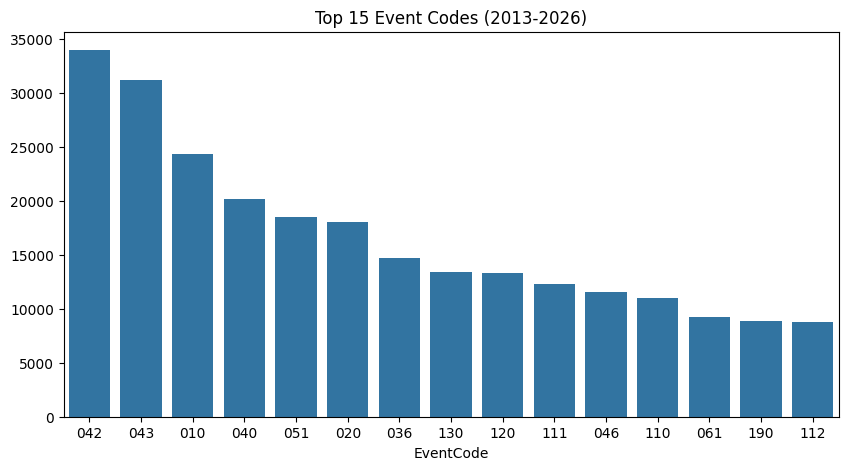

위협 및 무력 관련 사건 수: 12828건


In [15]:
# 가장 많이 발생하는 사건 코드 TOP 15
event_dist = df['EventCode'].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=event_dist.index, y=event_dist.values)
plt.title('Top 15 Event Codes (2013-2026)')
plt.show()

# 160(협박), 190(무력사용) 등 코드가 실제로 존재하는지 확인
critical_codes = ['160', '190', '193'] # 193은 전술적 무력 행사 등
exists = df[df['EventCode'].isin(critical_codes)]
print(f"위협 및 무력 관련 사건 수: {len(exists)}건")

- 042 협의 - 방문 실행
- 043 협의 - 방문 접대
- 010 공식 성명 발표 - 일반 성명 (특정되지 않음)
- 040 협의 - 협의 (특정되지 않음)
- 051 외교적 협력 실행 - 외교 관계 수립 / 개선
- 020 호소 및 요청 - 호소 및 요청 (특정되지 않음)
- 036 협력 의사 표명 - 만남/협상 의사
- 130 위협 - 위협 (특정되지 않음)
- 120 거부 - 거부 (특정되지 않음)
- 111 반대 - 비판 / 비난
- 046 협의 - 협상 참여
- 110 반대 - 반대 (특정되지 않음)
- 061 물질적 협력 실행 - 경제 협력
- 190 교전 - 정규군 사용 (특정되지 않음)
- 112 반대 - 혐의 제기

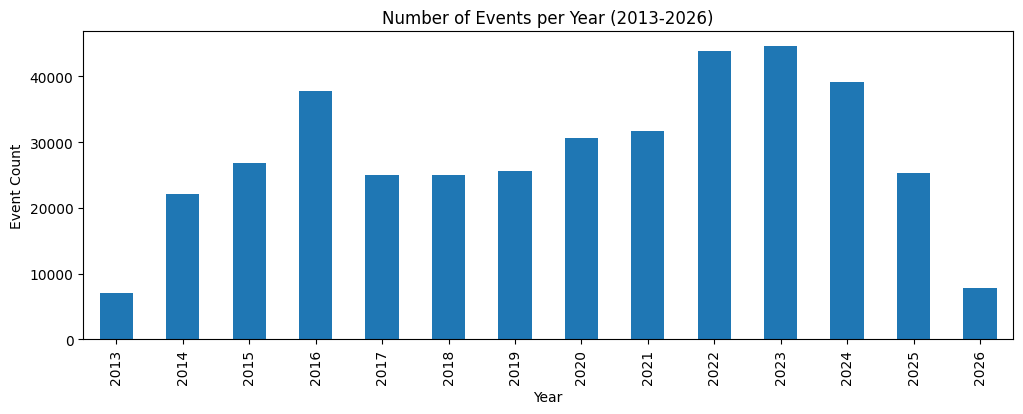

In [ ]:
# 연도별 사건 수 집계
yearly_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
yearly_counts.plot(kind='bar')
plt.title('Number of Events per Year (2013-2026)')
plt.ylabel('Event Count')
plt.show()

뉴스 원문(URL) 샘플 검증

In [17]:
# 가장 극단적인 갈등 사건 3건 추출
sample_conflicts = df.sort_values('GoldsteinScale').head(3)

print("--- [심각한 갈등 사건 뉴스 샘플] ---")
for i, row in sample_conflicts.iterrows():
    print(f"날짜: {row['SQLDATE']} | 지수: {row['GoldsteinScale']}")
    print(f"뉴스 URL: {row['SOURCEURL']}\n")

--- [심각한 갈등 사건 뉴스 샘플] ---
날짜: 2022-08-30 00:00:00 | 지수: -10.0
뉴스 URL: https://article.wn.com/view/2022/08/30/Taiwan_fires_warning_shots_at_Chinese_drone/

날짜: 2022-08-30 00:00:00 | 지수: -10.0
뉴스 URL: https://www.theguardian.com/world/2022/aug/30/taiwan-fires-warning-shots-at-chinese-drone

날짜: 2022-08-30 00:00:00 | 지수: -10.0
뉴스 URL: https://article.wn.com/view/2022/08/30/Taiwan_fires_warning_shots_at_Chinese_drone/



In [19]:
# 컬럼(NumMentions, AvgTone) 추가
updated_query = """
SELECT 
    SQLDATE, 
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone, 
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE Year BETWEEN 2013 AND 2026
  AND (
    (Actor1Code = 'CHN' AND Actor2Code = 'TWN') OR 
    (Actor1Code = 'TWN' AND Actor2Code = 'CHN')
  )
"""

# 2. 데이터 다시 불러오기
df = pandas_gbq.read_gbq(updated_query, project_id=project_id, credentials=credentials)

print("데이터 업데이트 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 업데이트 완료


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20161225,1722,-5.0,2,-3.305785,35.0000,105.000,http://news.ltn.com.tw/news/focus/breakingnews...
1,20161225,041,1.0,2,-2.298851,20.0000,77.000,http://zeenews.india.com/news/world/china-airc...
2,20161225,113,-2.0,1,-1.286765,23.5000,121.000,https://www.hongkongfp.com/2016/12/26/chinese-...
3,20161225,113,-2.0,1,-1.286765,27.8603,116.464,https://www.hongkongfp.com/2016/12/26/chinese-...
4,20161225,041,1.0,1,-2.298851,38.0000,-97.000,http://zeenews.india.com/news/world/china-airc...


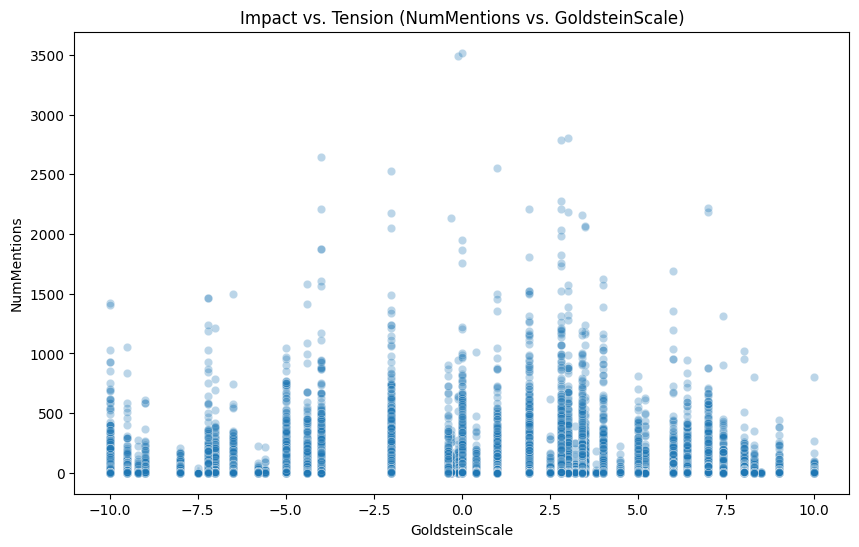

In [20]:
# 영향력 있는 사건만 보기 위해 상관관계 확인
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GoldsteinScale', y='NumMentions', alpha=0.3)
plt.title('Impact vs. Tension (NumMentions vs. GoldsteinScale)')
plt.show()

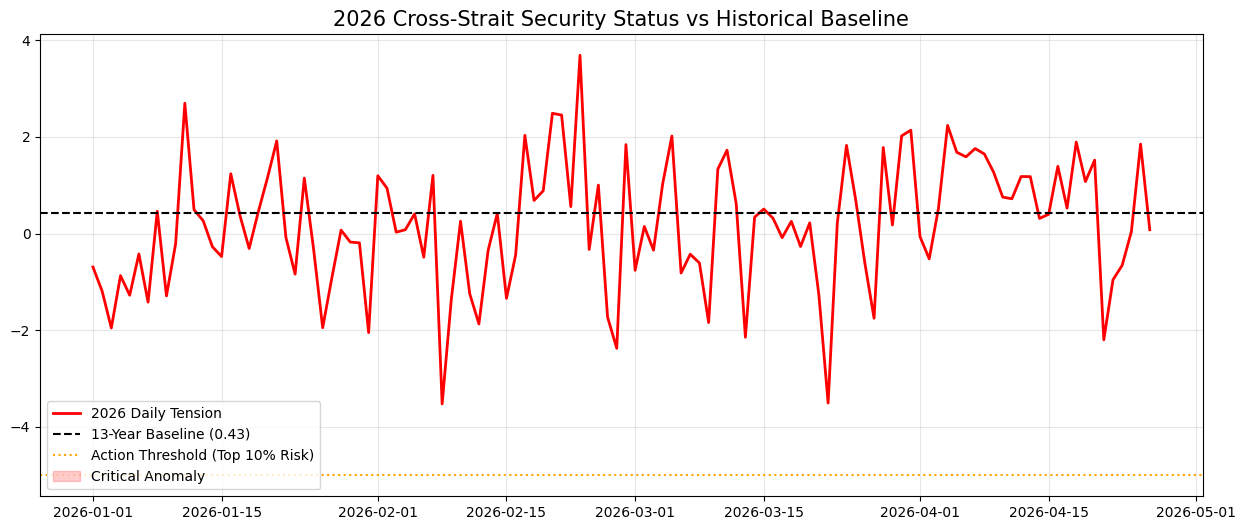

In [21]:
# 데이터 전처리
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
df['Year'] = df['SQLDATE'].dt.year

# 1. 2025년까지의 평균 (Baseline) vs 2026년 (Current)
baseline = df[df['Year'] < 2026]['GoldsteinScale'].mean()
current_2026 = df[df['Year'] == 2026].groupby('SQLDATE')['GoldsteinScale'].mean()

plt.figure(figsize=(15, 6))
plt.plot(current_2026.index, current_2026.values, label='2026 Daily Tension', color='red', linewidth=2)
plt.axhline(baseline, color='black', linestyle='--', label=f'13-Year Baseline ({baseline:.2f})')

# 갈등 임계치 설정 (예: 하위 10% 수준)
threshold = df['GoldsteinScale'].quantile(0.1)
plt.axhline(threshold, color='orange', linestyle=':', label='Action Threshold (Top 10% Risk)')

plt.fill_between(current_2026.index, current_2026.values, threshold, 
                 where=(current_2026.values < threshold), color='red', alpha=0.2, label='Critical Anomaly')

plt.title('2026 Cross-Strait Security Status vs Historical Baseline', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Jua\AppData\Local\Temp\ipykernel_23912\3516096667.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_resampled = df.resample('M', on='SQLDATE')[['GoldsteinScale', 'AvgTone']].mean()


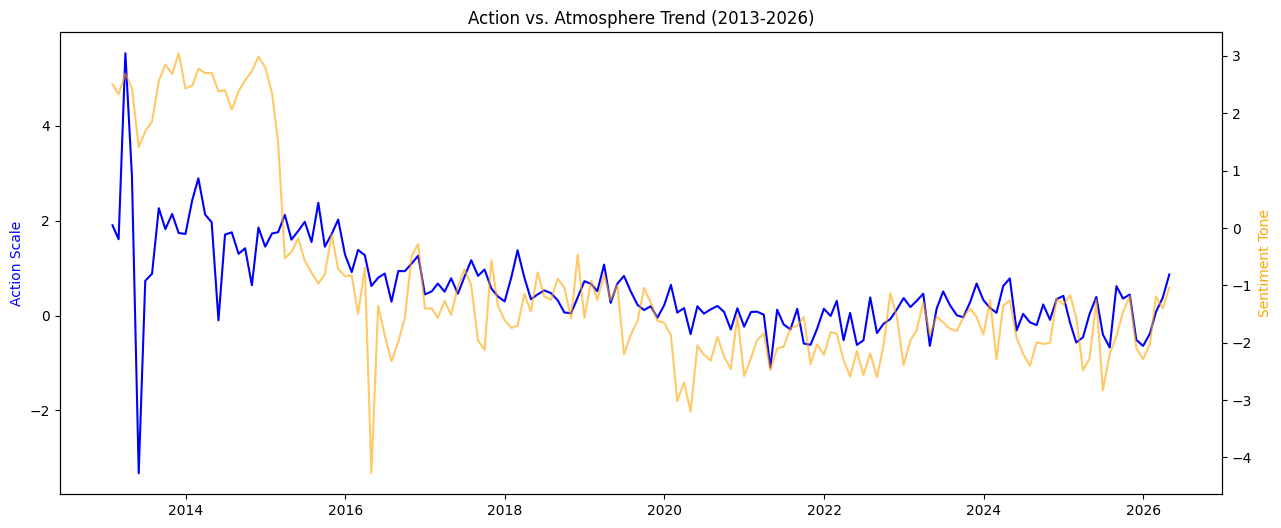

In [24]:
df_resampled = df.resample('M', on='SQLDATE')[['GoldsteinScale', 'AvgTone']].mean()

fig, ax1 = plt.subplots(figsize=(15, 6))

ax2 = ax1.twinx()
ax1.plot(df_resampled.index, df_resampled['GoldsteinScale'], color='blue', label='Action (Goldstein)')
ax2.plot(df_resampled.index, df_resampled['AvgTone'], color='orange', label='Atmosphere (AvgTone)', alpha=0.6)

ax1.set_ylabel('Action Scale', color='blue')
ax2.set_ylabel('Sentiment Tone', color='orange')
plt.title('Action vs. Atmosphere Trend (2013-2026)')
plt.show()

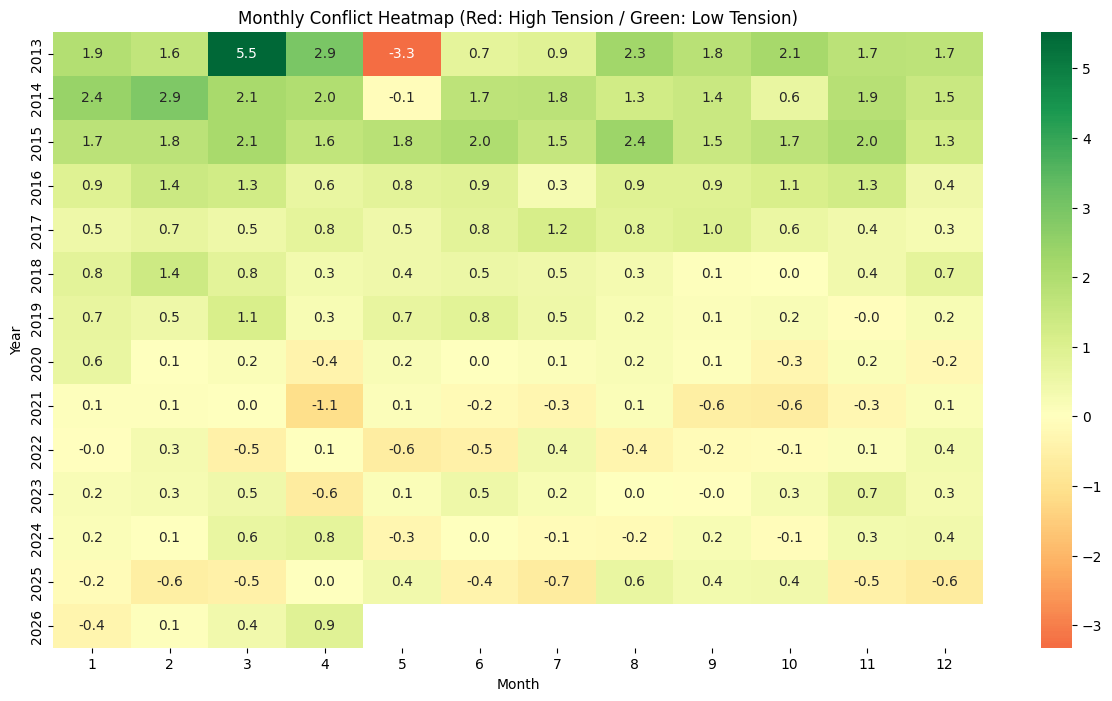

In [25]:
# 연도별/월별 갈등 주기성 분석

df['Month'] = df['SQLDATE'].dt.month
pivot_table = df.pivot_table(values='GoldsteinScale', index='Year', columns='Month', aggfunc='mean')

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap='RdYlGn', center=0, annot=True, fmt=".1f")
plt.title('Monthly Conflict Heatmap (Red: High Tension / Green: Low Tension)')
plt.show()

필터링 기준을 Actor1CountryCode컬럼으로 변경
Actor1Code: 전체 CAMEO 코드(CHNGOV, CHNMIL, CHN)로 행위자의 구체적 성격(정부, 군 등)까지 포함
Actor1CountryCode: 국가 식별 코드(CHN)로 국가 단위의 모든 행위자를 한 번에 포착

In [6]:
query = """
SELECT 
    SQLDATE, 
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE Year BETWEEN 2013 AND 2026
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  """

# 2. 데이터 다시 불러오기
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("데이터 업데이트 완료")
display(df.head())

Downloading: 100%|██████████|
데이터 업데이트 완료


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20220829,193,-10.0,2,-1.696970,35.0000,105.000,https://sofrep.com/news/china-irate-over-1b-us...
1,20220829,193,-10.0,6,-1.696970,35.0000,105.000,https://sofrep.com/news/china-irate-over-1b-us...
2,20220905,070,7.0,2,-4.155125,25.0478,121.532,https://www.taiwannews.com.tw/en/news/4648626
3,20220905,194,-10.0,5,-2.010582,24.0000,121.000,https://www.mis-asia.com/News/What-are-Nitroge...
4,20220905,194,-10.0,16,-4.521277,29.5441,115.450,http://dailyorange.com/2022/09/taiwanese-chine...


In [9]:
# 데이터의 기본 정보 요약
print("--- [데이터 구조 확인] ---")
print(df.info())

# 결측치(NaN) 확인 - 리포트 신뢰도와 직결
print("\n--- [결측치 비율 (%)] ---")
print(df.isnull().mean() * 100)

# 주요 수치 데이터의 기초 통계량 (평균, 최소, 최대, 4분위수)
print("\n--- [주요 수치 통계] ---")
display(df[['GoldsteinScale']].describe())

--- [데이터 구조 확인] ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492766 entries, 0 to 492765
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   SQLDATE         492766 non-null  Int64  
 1   EventCode       492766 non-null  object 
 2   GoldsteinScale  492764 non-null  float64
 3   NumMentions     492766 non-null  Int64  
 4   AvgTone         492766 non-null  float64
 5   ActionGeo_Lat   492718 non-null  float64
 6   ActionGeo_Long  492720 non-null  float64
 7   SOURCEURL       492766 non-null  object 
dtypes: Int64(2), float64(4), object(2)
memory usage: 31.0+ MB
None

--- [결측치 비율 (%)] ---
SQLDATE           0.000000
EventCode         0.000000
GoldsteinScale    0.000406
NumMentions       0.000000
AvgTone           0.000000
ActionGeo_Lat     0.009741
ActionGeo_Long    0.009335
SOURCEURL         0.000000
dtype: float64

--- [주요 수치 통계] ---


,GoldsteinScale
count,492764.000000
mean,0.374547
std,4.366050
min,-10.000000
25%,-2.000000
50%,1.000000
75%,3.400000
max,10.000000


기사량(NumMentions) 분포 확인 및 최소 기준 설정

--- [기사량(NumMentions) 백분위수 분포] ---
0.50      4.0
0.75      8.0
0.90     17.0
0.95     32.0
0.99    132.0
Name: NumMentions, dtype: Float64


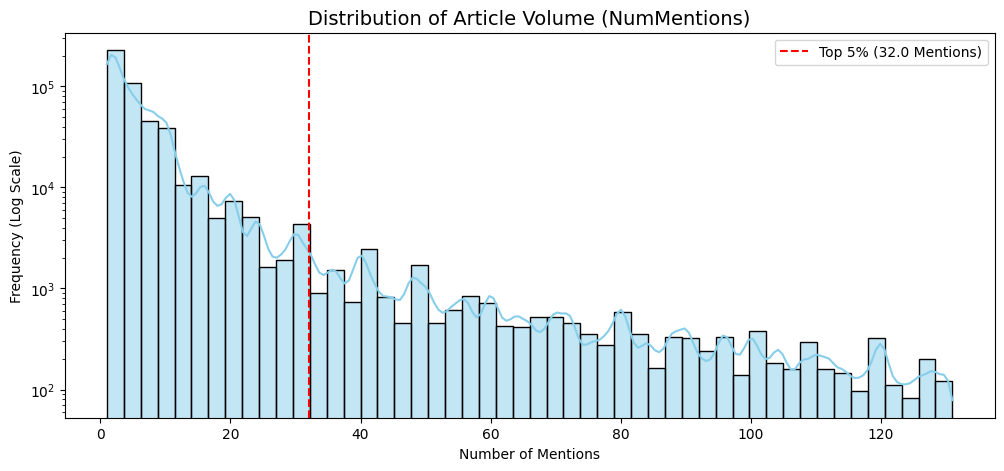

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 기사량 기초 통계량 확인 (상위 % 파악)
print("--- [기사량(NumMentions) 백분위수 분포] ---")
quantiles = df['NumMentions'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])
print(quantiles)

# 2. 기사량 분포 시각화 (너무 극단적인 값이 많아 상위 1%는 제외)
limit_99 = df['NumMentions'].quantile(0.99)
filtered_mentions = df[df['NumMentions'] < limit_99]

plt.figure(figsize=(12, 5))
sns.histplot(filtered_mentions['NumMentions'], bins=50, kde=True, color='skyblue')

# 백분위수 기준선 긋기 (예: 상위 5% 기준선)
threshold_95 = quantiles[0.95]
plt.axvline(threshold_95, color='red', linestyle='--', label=f'Top 5% ({threshold_95:.1f} Mentions)')

plt.title('Distribution of Article Volume (NumMentions)', fontsize=14)
plt.xlabel('Number of Mentions')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log') # 빈도 차이가 커서 로그 스케일 적용
plt.legend()
plt.show()

GoldsteinScale 분포 확인 및 임계값(Threshold) 설정


--- [GoldsteinScale 백분위수 분포 (위험도 순)] ---
0.01   -10.0
0.05    -7.2
0.10    -5.0
0.25    -2.0
0.50     1.0
Name: GoldsteinScale, dtype: float64


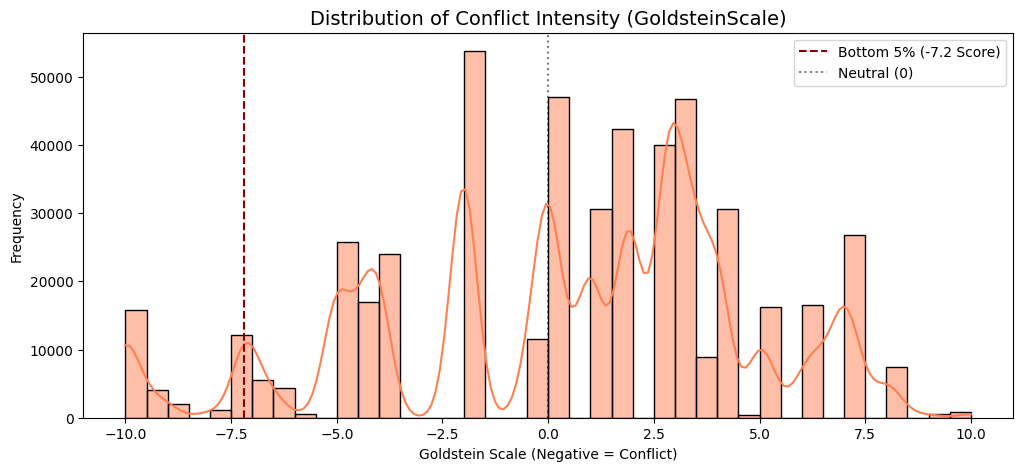

In [8]:
# 1. Goldstein 기초 통계량 (하위 % 파악 - 점수가 낮을수록 위험)
print("\n--- [GoldsteinScale 백분위수 분포 (위험도 순)] ---")
goldstein_quantiles = df['GoldsteinScale'].quantile([0.01, 0.05, 0.10, 0.25, 0.5])
print(goldstein_quantiles)

# 2. Goldstein 분포 시각화
plt.figure(figsize=(12, 5))
sns.histplot(df['GoldsteinScale'], bins=40, kde=True, color='coral')

# 백분위수 기준선 긋기 (예: 하위 5% 기준선)
threshold_bottom_5 = goldstein_quantiles[0.05]
plt.axvline(threshold_bottom_5, color='darkred', linestyle='--', label=f'Bottom 5% ({threshold_bottom_5:.1f} Score)')
plt.axvline(0, color='black', linestyle=':', alpha=0.5, label='Neutral (0)')

plt.title('Distribution of Conflict Intensity (GoldsteinScale)', fontsize=14)
plt.xlabel('Goldstein Scale (Negative = Conflict)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

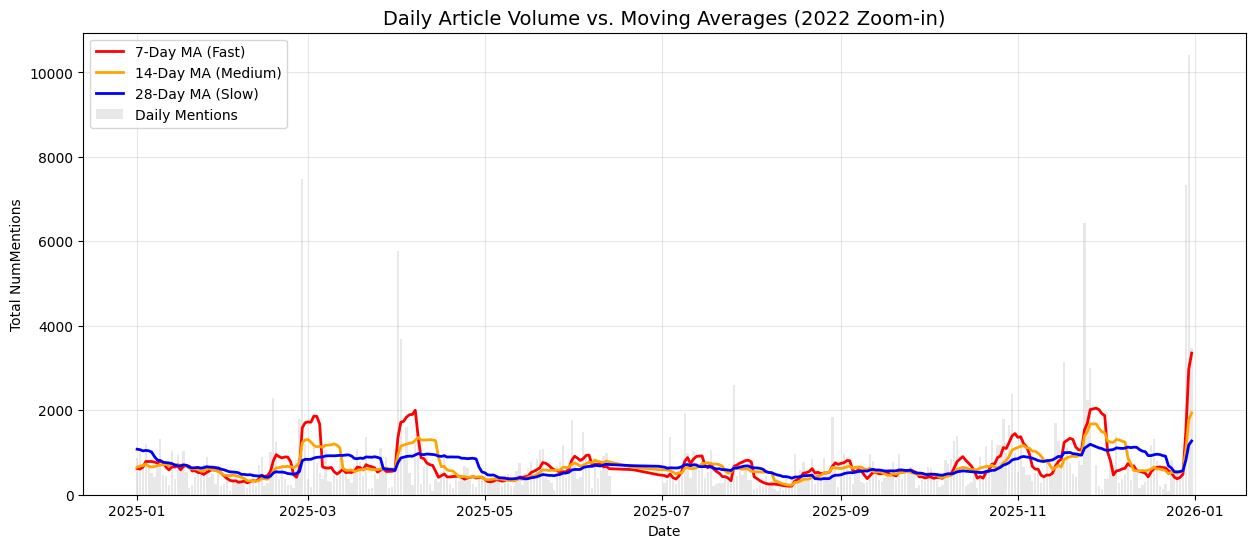

In [12]:
import pandas_gbq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 날짜 데이터 형식 변환 및 정렬
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

# 2. 일별 총 기사량(NumMentions) 집계
daily_volume = df.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 이동평균선(Rolling Mean) 계산
daily_volume['MA_7'] = daily_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_volume['MA_14'] = daily_volume['NumMentions'].rolling(window=14, min_periods=1).mean()
daily_volume['MA_28'] = daily_volume['NumMentions'].rolling(window=28, min_periods=1).mean()

# 4. 시각화(특정 연도만 확대)
start_date = '2025-01-01'
end_date = '2025-12-31'
mask = (daily_volume.index >= start_date) & (daily_volume.index <= end_date)
zoom_df = daily_volume.loc[mask]

plt.figure(figsize=(15, 6))

# 원본 일별 기사량은 옅은 막대그래프로 배경에 둡니다
plt.bar(zoom_df.index, zoom_df['NumMentions'], color='lightgray', alpha=0.5, label='Daily Mentions')

# 이동평균선 그리기
plt.plot(zoom_df.index, zoom_df['MA_7'], color='red', linewidth=2, label='7-Day MA (Fast)')
plt.plot(zoom_df.index, zoom_df['MA_14'], color='orange', linewidth=2, label='14-Day MA (Medium)')
plt.plot(zoom_df.index, zoom_df['MA_28'], color='blue', linewidth=2, label='28-Day MA (Slow)')

plt.title('Daily Article Volume vs. Moving Averages (2022 Zoom-in)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total NumMentions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

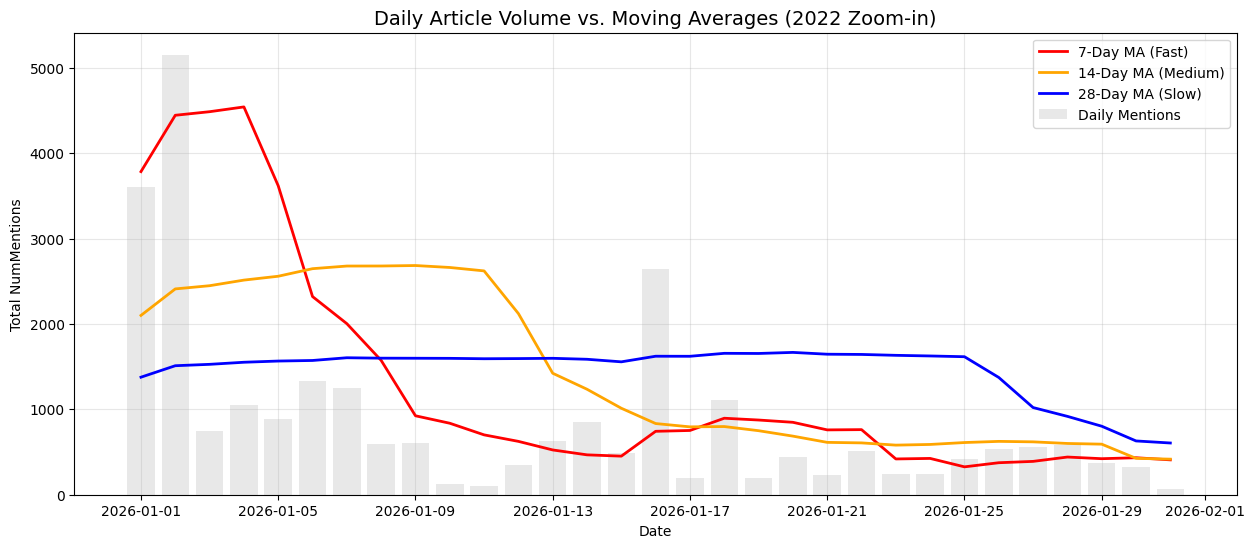

In [14]:
# 1. 날짜 데이터 형식 변환 및 정렬
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

# 2. 일별 총 기사량(NumMentions) 집계
daily_volume = df.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 이동평균선(Rolling Mean) 계산
daily_volume['MA_7'] = daily_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_volume['MA_14'] = daily_volume['NumMentions'].rolling(window=14, min_periods=1).mean()
daily_volume['MA_28'] = daily_volume['NumMentions'].rolling(window=28, min_periods=1).mean()

# 4. 시각화
start_date = '2026-01-01'
end_date = '2026-01-31'
mask = (daily_volume.index >= start_date) & (daily_volume.index <= end_date)
zoom_df = daily_volume.loc[mask]

plt.figure(figsize=(15, 6))

# 원본 일별 기사량은 옅은 막대그래프로 배경에 둡니다
plt.bar(zoom_df.index, zoom_df['NumMentions'], color='lightgray', alpha=0.5, label='Daily Mentions')

# 이동평균선 그리기
plt.plot(zoom_df.index, zoom_df['MA_7'], color='red', linewidth=2, label='7-Day MA (Fast)')
plt.plot(zoom_df.index, zoom_df['MA_14'], color='orange', linewidth=2, label='14-Day MA (Medium)')
plt.plot(zoom_df.index, zoom_df['MA_28'], color='blue', linewidth=2, label='28-Day MA (Slow)')

plt.title('Daily Article Volume vs. Moving Averages (2022 Zoom-in)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total NumMentions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

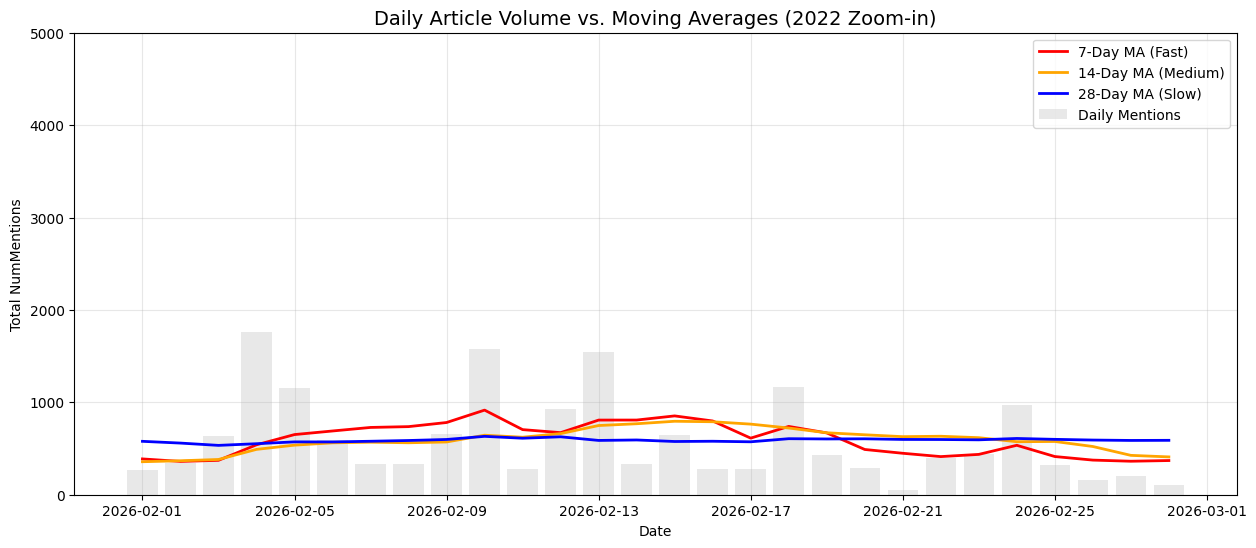

In [17]:
# 1. 날짜 데이터 형식 변환 및 정렬
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

# 2. 일별 총 기사량(NumMentions) 집계
daily_volume = df.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 이동평균선(Rolling Mean) 계산
daily_volume['MA_7'] = daily_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_volume['MA_14'] = daily_volume['NumMentions'].rolling(window=14, min_periods=1).mean()
daily_volume['MA_28'] = daily_volume['NumMentions'].rolling(window=28, min_periods=1).mean()

# 4. 시각화
start_date = '2026-02-01'
end_date = '2026-02-28'
mask = (daily_volume.index >= start_date) & (daily_volume.index <= end_date)
zoom_df = daily_volume.loc[mask]

plt.figure(figsize=(15, 6))

# 원본 일별 기사량은 옅은 막대그래프로 배경에 둡니다
plt.bar(zoom_df.index, zoom_df['NumMentions'], color='lightgray', alpha=0.5, label='Daily Mentions')

# 이동평균선 그리기
plt.plot(zoom_df.index, zoom_df['MA_7'], color='red', linewidth=2, label='7-Day MA (Fast)')
plt.plot(zoom_df.index, zoom_df['MA_14'], color='orange', linewidth=2, label='14-Day MA (Medium)')
plt.plot(zoom_df.index, zoom_df['MA_28'], color='blue', linewidth=2, label='28-Day MA (Slow)')

plt.title('Daily Article Volume vs. Moving Averages (2022 Zoom-in)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total NumMentions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.ylim(0, 5000)
plt.show()

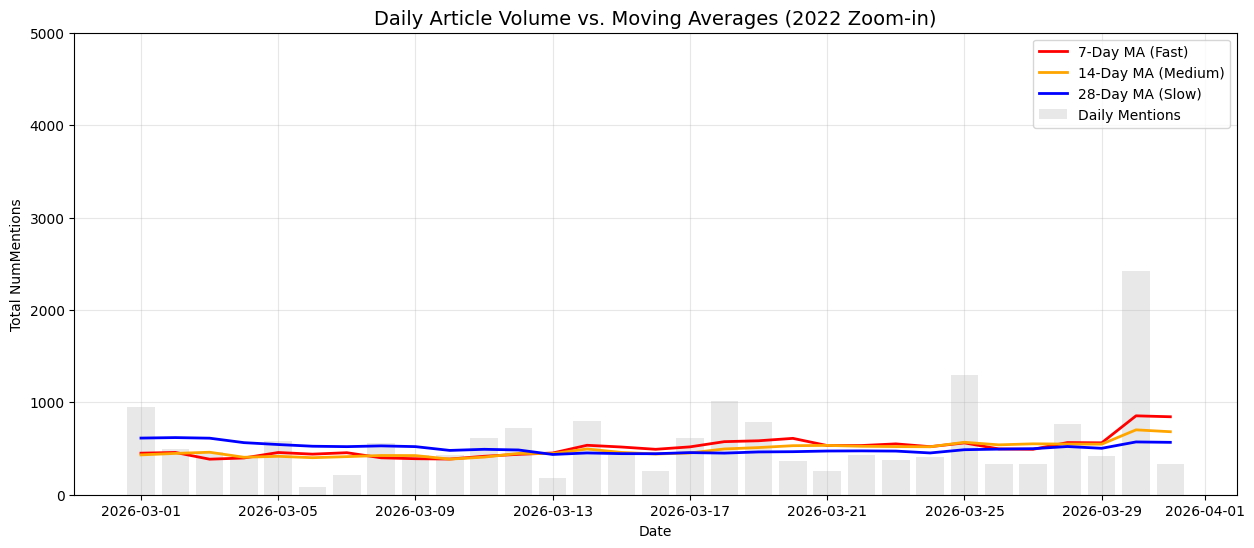

In [18]:
# 1. 날짜 데이터 형식 변환 및 정렬
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d', errors='coerce')

# 2. 일별 총 기사량(NumMentions) 집계
daily_volume = df.groupby('SQLDATE')['NumMentions'].sum().to_frame()

# 3. 이동평균선(Rolling Mean) 계산
daily_volume['MA_7'] = daily_volume['NumMentions'].rolling(window=7, min_periods=1).mean()
daily_volume['MA_14'] = daily_volume['NumMentions'].rolling(window=14, min_periods=1).mean()
daily_volume['MA_28'] = daily_volume['NumMentions'].rolling(window=28, min_periods=1).mean()

# 4. 시각화
start_date = '2026-03-01'
end_date = '2026-03-31'
mask = (daily_volume.index >= start_date) & (daily_volume.index <= end_date)
zoom_df = daily_volume.loc[mask]

plt.figure(figsize=(15, 6))

# 원본 일별 기사량은 옅은 막대그래프로 배경에 둡니다
plt.bar(zoom_df.index, zoom_df['NumMentions'], color='lightgray', alpha=0.5, label='Daily Mentions')

# 이동평균선 그리기
plt.plot(zoom_df.index, zoom_df['MA_7'], color='red', linewidth=2, label='7-Day MA (Fast)')
plt.plot(zoom_df.index, zoom_df['MA_14'], color='orange', linewidth=2, label='14-Day MA (Medium)')
plt.plot(zoom_df.index, zoom_df['MA_28'], color='blue', linewidth=2, label='28-Day MA (Slow)')

plt.title('Daily Article Volume vs. Moving Averages (2022 Zoom-in)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total NumMentions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.ylim(0, 5000)
plt.show()